# Challenger O-rings: critical re-examination of the pre-launch analysis

On January 27, 1986, the night before the launch, NASA and Morton Thiokol
discussed the risk of launching at 31°F (about -0.5°C). The analysis we were given
concluded that temperature had no visible effect on O-ring damage.

In this notebook I redo that analysis and I identify three errors of reasoning:

1. **Key data were excluded**: flights with no O-ring damage were removed.
2. **Uncertainty was ignored**: a very wide confidence interval was read as "no effect".
3. **Extrapolation without data**: the model was used at 31°F although the
   coldest flight in the dataset is at 53°F.

I also found a fourth flaw that affects the final number: the analysis used a
global failure rate that does not depend on temperature.

Data: 23 flights, with the number of damaged O-rings (out of 6) per flight,
temperature (°F) and pressure (psi).

## 1. Loading the data

I keep **all 23 flights**. The original analysis filtered the data at this stage. I also print the temperature range, because I will need it
for the prediction

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

data = pd.read_csv("shuttle.csv")

print(data.shape)

# Range of observed temperatures: 53 to 81 °F
# The launch was forecast at 31 °F far below the coldest tested flight
print(data.Temperature.min(), data.Temperature.max())

(23, 5)
53 81


## 2. Preparing the variables

I create three columns:

- `Frequency`: fraction of damaged O-rings per flight (out of 6).
- `Success`: number of undamaged O-rings. I need both the failures and the
  successes for the binomial model, because each flight is 6 trials.
- `Intercept`: constant term of the model.

I then compare the temperatures of flights with and without damage. Flights
without damage are on average much warmer (72.1 °F vs 63.7 °F). These are
exactly the flights that the original analysis removed.

In [3]:
# Fraction of damaged O-rings per flight
data["Frequency"] = data.Malfunction / data.Count

# Number of undamaged O-rings
data["Success"] = data.Count - data.Malfunction

# Constant column for the intercept of the regression
data["Intercept"] = 1

# I compare temperatures of flights with (True) and without (False) damage
print(data.groupby(data.Malfunction > 0).Temperature.describe())

             count       mean       std   min    25%   50%   75%   max
Malfunction                                                           
False         16.0  72.125000  4.842520  66.0  67.75  71.0  76.0  81.0
True           7.0  63.714286  8.159132  53.0  57.50  63.0  70.0  75.0


## 3. Visual inspection (error 1 corrected)

The original notebook plotted only the 7 flights with at least one failure and
concluded that "the dependence does not look very important". This is a flaw in
itself: if I keep only flights where Frequency > 0, no trend can appear.
The selection guarantees it.

Here I plot all 23 flights, including the zeros.

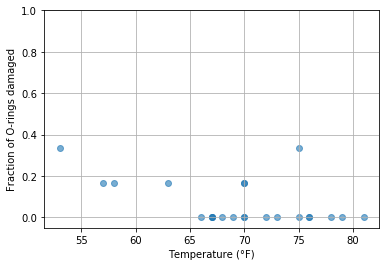

In [4]:
fig, ax = plt.subplots()

ax.scatter(data.Temperature, data.Frequency, alpha=0.6)

ax.set_xlabel("Temperature (°F)")
ax.set_ylabel("Fraction of O-rings damaged")

ax.set_ylim(-0.05, 1)
ax.grid(True)
plt.show()

**What I observe:** damage is more frequent at low temperatures, and all the
flights below 63 °F had at least one damaged O-ring. There are also a few
failures at 70 °F and 75 °F, and no flight without damage below 66 °F. This
motivates a model, but I cannot conclude anything from the plot alone with so
few points

## 4. Logistic regression

I use the same model family as the original analysis (binomial GLM, logit link),
so that only the data changes. Each flight has 6 O-rings, so my response is the
pair (number damaged, number undamaged).

Model: p(t) = exp(a·t + b) / (1 + exp(a·t + b))

In [6]:
X = data[["Intercept", "Temperature"]]

y = data[["Malfunction", "Success"]]

logmodel = sm.GLM(
    y, X, family=sm.families.Binomial(sm.families.links.logit)
).fit()

print(logmodel.summary())

                     Generalized Linear Model Regression Results                      
Dep. Variable:     ['Malfunction', 'Success']   No. Observations:                   23
Model:                                    GLM   Df Residuals:                       21
Model Family:                        Binomial   Df Model:                            1
Link Function:                          logit   Scale:                          1.0000
Method:                                  IRLS   Log-Likelihood:                -15.823
Date:                        Wed, 07 Oct 2026   Deviance:                       18.086
Time:                                19:58:09   Pearson chi2:                     30.0
No. Iterations:                             6   Covariance Type:             nonrobust
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       5.0850      3.052      1.666      0.096  

**My result:** the temperature coefficient is **-0.1156** (standard error 0.047,
95% interval [-0.208, -0.023], p = 0.014). The interval excludes 0, so I conclude
that lower temperature is associated with a higher probability of damage.

In the original analysis the coefficient was +0.0014 with an interval of
[-0.238, 0.240] (error 2). With such a wide interval, the right reading is
"we cannot tell", not "there is no effect". The original conclusion mistook a
lack of information for an absence of effect.

## 5. Interpreting the coefficient

A logit coefficient is hard to read directly, so I exponentiate it to get an
**odds ratio**. I also scale it to 10 °F, which is easier to interpret physically.

In [7]:
ci = logmodel.conf_int(alpha=0.05).loc["Temperature"]

print(np.exp(logmodel.params["Temperature"]), np.exp(ci[0]), np.exp(ci[1]))

print(np.exp(10 * logmodel.params["Temperature"]),
      np.exp(10 * ci[0]), np.exp(10 * ci[1]))

0.8908304453269525 0.812396983582632 0.9768363230766459
0.31473896485064773 0.12522268801768935 0.791075623462608


**My result:** each additional °F multiplies the odds of damage by about 0.89
(interval 0.81 to 0.98). For +10 °F the factor is 0.31 (interval 0.13 to 0.79);
equivalently, each 10 °F **colder** multiplies the odds by about 3.2.

*My caveat:* an odds ratio is not a probability, and I am assuming it is constant
over the whole temperature range, which is a modelling assumption.

## 6. Prediction with uncertainty (errors 2 and 3 corrected)

Two things were missing in the original plot, and I add them:

- **Uncertainty**: the original drew a single curve. I show the 95% confidence
  band of the prediction.
- **Extrapolation**: the original drew the curve down to 30 °F with no warning,
  although there is no data below 53 °F. I shade the region without data in grey.

To get the band, I compute the uncertainty of the linear predictor a·t + b from
the covariance matrix of the coefficients, then transform the bounds with the
logistic function so that they stay between 0 and 1.

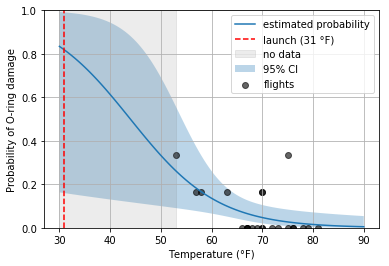

In [8]:
from scipy import stats

def predict_ci(model, temps, alpha=0.05):
    """Predicted probability and 95% confidence interval at the given temperatures."""
    temps = np.atleast_1d(temps).astype(float)

    Xp = np.column_stack([np.ones(len(temps)), temps])

    eta = Xp @ model.params.values

    se = np.sqrt(np.einsum("ij,jk,ik->i", Xp, model.cov_params().values, Xp))

    z = stats.norm.ppf(1 - alpha / 2)
    logistic = lambda e: 1 / (1 + np.exp(-e))
    return logistic(eta), logistic(eta - z * se), logistic(eta + z * se)

temps = np.linspace(30, 90, 121)
mean, lower, upper = predict_ci(logmodel, temps)

fig, ax = plt.subplots()
ax.plot(temps, mean, label="estimated probability")

ax.fill_between(temps, lower, upper, alpha=0.3, label="95% CI")

ax.scatter(data.Temperature, data.Frequency, color="k", alpha=0.6, label="flights")

ax.axvspan(30, data.Temperature.min(), color="grey", alpha=0.15, label="no data")

ax.axvline(31, color="r", ls="--", label="launch (31 °F)")

ax.set_xlabel("Temperature (°F)")
ax.set_ylabel("Probability of O-ring damage")
ax.set_ylim(0, 1)
ax.legend()
ax.grid(True)
plt.show()

**What I observe:** the probability rises steeply when temperature decreases. The
band is narrow within the data and very wide in the grey zone: at 31 °F I am
extrapolating, and my estimate is poorly constrained.

*My caveat:* the band only reflects parameter uncertainty **inside my model**.
It does not cover the possibility that the model itself is wrong outside the
data (for example, rubber behaving differently near freezing).

## 7. Risk at the launch temperature (error 4 corrected)

The original analysis used a **global** failure rate (9 damaged O-rings out of
138, p = 0.065). This is an average dominated by warm flights, so it says nothing
about 31 °F. It then computed:

- p² = probability that both the primary and secondary O-ring of a joint fail
  (assuming independence);
- 1 - (1 - p²)³ = probability that at least one of the 3 joints fails
  (assuming independence), which gave about 1.2%.

I apply the same formula, but with **p(31 °F) from my model**, and I carry the
confidence interval through the computation.

In [9]:
mean31, lower31, upper31 = predict_ci(logmodel, 31)

for name, p in [("estimate", mean31[0]),
                ("lower", lower31[0]),
                ("upper", upper31[0])]:
    print(name, round(p, 3), round(1 - (1 - p**2) ** 3, 3))

estimate 0.818 0.964
lower 0.16 0.074
upper 0.991 1.0


| | p(31 °F) | P(at least one joint fails both O-rings) |
|---|---|---|
| My estimate | 0.818 | **96.4%** |
| Lower bound of the interval | 0.160 | 7.4% |
| Upper bound of the interval | 0.991 | about 100% |

The original analysis gave 1.2%. Even the most optimistic end of my interval is
about six times higher.

*My caveats:* the formula assumes independence between rings and between joints,
which I find questionable because they share the same flight conditions. The
honest conclusion is "very likely dangerous, with a poorly known magnitude",
not "exactly 96%".

## 8. Robustness check: pressure

The introduction mentioned pressure, but the original analysis never modelled it.
I add it as a second explanatory variable to check whether it explains the damage
instead of temperature.

In [10]:
X2 = data[["Intercept", "Temperature", "Pressure"]]
m2 = sm.GLM(
    y, X2, family=sm.families.Binomial(sm.families.links.logit)
).fit()
print(m2.summary().tables[1])

                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       2.5202      3.487      0.723      0.470      -4.314       9.354
Temperature    -0.0983      0.045     -2.190      0.029      -0.186      -0.010
Pressure        0.0085      0.008      1.105      0.269      -0.007       0.024


**My result:** temperature stays negative and significant (-0.098, p = 0.029),
while pressure is not significant (0.0085, p = 0.27). So pressure does not remove
the temperature effect.

*My caveat:* pressure takes only 3 values (50, 100, 200) and is tied to the launch
date, so I cannot cleanly separate it from other changes over the years

## 9. Robustness check: dependence on the coldest flight

The 53 °F flight (2 damaged O-rings) has a lot of leverage on the fit. I refit
the model without it to see whether my conclusion holds

In [11]:
# I remove the coldest flight (53 °F) and refit the same model
d_ = data[data.Temperature > 53]
m3 = sm.GLM(
    d_[["Malfunction", "Success"]],
    d_[["Intercept", "Temperature"]],
    family=sm.families.Binomial(sm.families.links.logit),
).fit()
print(m3.summary().tables[1])

                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       3.5360      4.143      0.853      0.393      -4.584      11.656
Temperature    -0.0934      0.061     -1.520      0.129      -0.214       0.027


**My result:** the coefficient stays negative (-0.093) but is no longer
significant (interval [-0.214, 0.027], p = 0.129). The evidence for a temperature
effect therefore depends heavily on a single cold flight, and I think this should
be reported, not hidden.

It also suggests a decision rule to me: with so little data at low temperatures,
the burden of proof should be on showing that the launch is safe, not on proving
that it is dangerous.


## Conclusion

I found that the original analysis underestimated the risk because of three
errors of reasoning:

1. It **excluded the flights without damage**, which hid the temperature effect.
2. It **ignored the uncertainty** and read a very wide interval as "no effect".
3. It **extrapolated to 31 °F** with no data below 53 °F, and it used a global
   failure rate that did not depend on temperature.

With all 23 flights, I find that temperature has a significant negative effect on
the probability of O-ring damage. My estimated risk at 31 °F is far higher than
the reported 1.2%, but my interval is very wide because the launch is far outside
the observed range. My conclusions rely on independence assumptions and on a small
number of cold flights (section 9)